# ACS Exploratory Data Analysis
## Project Setup

In [181]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [182]:
# Import Dataset
acs = pd.read_csv("pums_short.csv.gz")

## Data Overview

In [183]:
print(f"Rows: {acs.shape[0]}")
print(f"Columns: {acs.shape[1]}")

Rows: 276632
Columns: 31


In [184]:
acs.head()

,DIVISION,PUMA,REGION,ST,NP,MRGP,RNTP,TEN,VALP,VEH,...,NRC,PARTNER,R18,R60,R65,TAXAMT,WIF,WKEXREL,WORKSTAT,FFINCP
0,6,800,3,1,4,550.0,NaN,1.0,60000.0,4.0,...,1.0,0.0,1.0,0.0,0.0,325.0,3.0,1.0,1.0,0
1,6,2500,3,1,1,NaN,NaN,2.0,120000.0,1.0,...,0.0,0.0,0.0,1.0,1.0,625.0,NaN,NaN,NaN,0
2,6,2702,3,1,3,NaN,120.0,3.0,NaN,2.0,...,2.0,0.0,1.0,0.0,0.0,NaN,0.0,15.0,15.0,0
3,6,1303,3,1,1,NaN,650.0,3.0,NaN,1.0,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0
4,6,2000,3,1,5,NaN,950.0,3.0,NaN,3.0,...,1.0,0.0,1.0,0.0,0.0,NaN,3.0,2.0,1.0,0


### Column Names

In [185]:
acs.columns.all

<bound method Index.all of Index(['DIVISION', 'PUMA', 'REGION', 'ST', 'NP', 'MRGP', 'RNTP', 'TEN', 'VALP',
       'VEH', 'YBL', 'FES', 'FINCP', 'FPARC', 'HHT', 'HINCP', 'HUPAC', 'MV',
       'NOC', 'NPF', 'NR', 'NRC', 'PARTNER', 'R18', 'R60', 'R65', 'TAXAMT',
       'WIF', 'WKEXREL', 'WORKSTAT', 'FFINCP'],
      dtype='str')>

### Column Types

In [186]:
acs.info()

<class 'pandas.DataFrame'>
RangeIndex: 276632 entries, 0 to 276631
Data columns (total 31 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   DIVISION  276632 non-null  int64  
 1   PUMA      276632 non-null  int64  
 2   REGION    276632 non-null  int64  
 3   ST        276632 non-null  int64  
 4   NP        276632 non-null  int64  
 5   MRGP      103923 non-null  float64
 6   RNTP      73904 non-null   float64
 7   TEN       251019 non-null  float64
 8   VALP      178988 non-null  float64
 9   VEH       251019 non-null  float64
 10  YBL       276632 non-null  int64  
 11  FES       164443 non-null  float64
 12  FINCP     165749 non-null  float64
 13  FPARC     165749 non-null  float64
 14  HHT       251019 non-null  float64
 15  HINCP     251019 non-null  float64
 16  HUPAC     251019 non-null  float64
 17  MV        251019 non-null  float64
 18  NOC       251019 non-null  float64
 19  NPF       165749 non-null  float64
 20  NR        25101

### Variable of Interest

In [187]:
selected_cols = [
    "DIVISION",
    "REGION",
    "ST",
    "HINCP",    # household income
    "FINCP",    # family income
    "VALP",     # property value
    "RNTP",     # monthly rent
    "R65",      # presence of people 65+
    "TEN",      # tenure / ownership
    "NP",       # number of persons
    "VEH"       # vehicles
]

acs_selected = acs[selected_cols].copy()
acs_selected.head()

,DIVISION,REGION,ST,HINCP,FINCP,VALP,RNTP,R65,TEN,NP,VEH
0,6,3,1,70000.0,70000.0,60000.0,NaN,0.0,1.0,4,4.0
1,6,3,1,7000.0,NaN,120000.0,NaN,1.0,2.0,1,1.0
2,6,3,1,9000.0,9000.0,NaN,120.0,0.0,3.0,3,2.0
3,6,3,1,52000.0,NaN,NaN,650.0,0.0,3.0,1,1.0
4,6,3,1,74800.0,74800.0,NaN,950.0,0.0,3.0,5,3.0


## Missing Values

In [188]:
missing_summary = (
    acs_selected.isna()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

missing_summary.columns = ["column", "missing_proportion"]
missing_summary

,column,missing_proportion
0,RNTP,0.732844
1,FINCP,0.400832
2,VALP,0.352974
3,R65,0.092589
4,TEN,0.092589
5,VEH,0.092589
6,HINCP,0.092589
7,ST,0.000000
8,REGION,0.000000
9,DIVISION,0.000000


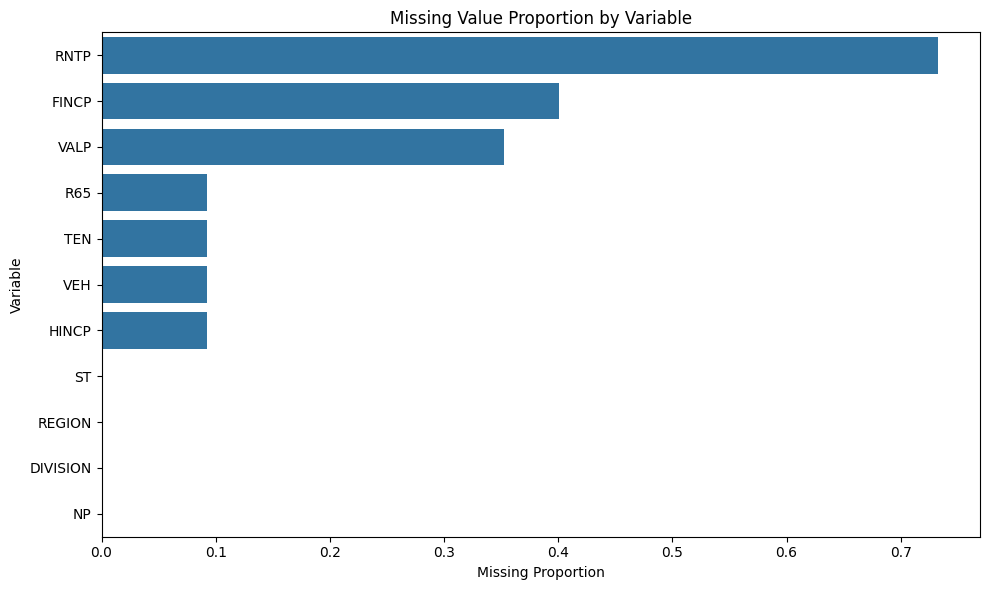

In [189]:
plt.figure(figsize=(10, 6))
sb.barplot(
    data=missing_summary,
    x="missing_proportion",
    y="column"
)
plt.title("Missing Value Proportion by Variable")
plt.xlabel("Missing Proportion")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

The "RNTP" (monthly rant) has substantial misses because the rent only applies to rental housing units.

# Division
From the page 1 of the codebook, `DIVISION` represents *Division code based on 2018 Census definitions*, which is **a catagrical nominal dataset**.
* 0 .Puerto Rico
* 1 .New England (Northeast region)
* 2 .Middle Atlantic (Northeast region)
* 3 .East North Central (Midwest region)
* 4 .West North Central (Midwest region)
* 5 .South Atlantic (South region)
* 6 .East South Central (South region)
* 7 .West South Central (South Region)
* 8 .Mountain (West region)
* 9 .Pacific (West region)

In [190]:
div_name = {
    0: "Puerto Rico",
    1: "New England (Northeast region)",
    2: "Middle Atlantic (Northeast region)",
    3: "East North Central (Midwest region)",
    4: "West North Central (Midwest region)",
    5: "South Atlantic (South region)",
    6: "East South Central (South region)",
    7: "West South Central (South Region)",
    8: "Mountain (West region)",
    9: "Pacific (West region)",
}

acs_selected["DIVISION"].value_counts().sort_index()
acs_selected["DIVISION_name"] = acs_selected["DIVISION"].replace(div_name)
acs_selected["DIVISION_name"]

0         East South Central (South region)
1         East South Central (South region)
2         East South Central (South region)
3         East South Central (South region)
4         East South Central (South region)
                        ...                
276627               Mountain (West region)
276628               Mountain (West region)
276629               Mountain (West region)
276630               Mountain (West region)
276631               Mountain (West region)
Name: DIVISION_name, Length: 276632, dtype: object

## Monthly Rent

In [191]:
total_rntp = acs_selected["RNTP"].shape[0]
valid_rntp = acs_selected["RNTP"].count()
print(f"\"RNTP\" has", total_rntp, "rows in total.")
print(f"\"RNTP\" has", valid_rntp, "valid rows.")

"RNTP" has 276632 rows in total.
"RNTP" has 73904 valid rows.


In [192]:
rntp = acs["RNTP"].dropna()
print("=== Monthly Rant Head ===")
rntp.head(5)

=== Monthly Rant Head ===


2     120.0
3     650.0
4     950.0
11    400.0
15    300.0
Name: RNTP, dtype: float64

In [193]:
print("=== Monthly Rant Summary ===")
rntp.describe()

=== Monthly Rant Summary ===


count    73904.000000
mean      1030.910289
std        663.433898
min          4.000000
25%        580.000000
50%        880.000000
75%       1300.000000
max       3900.000000
Name: RNTP, dtype: float64

In [194]:
rntp.max()-rntp.min()

np.float64(3896.0)

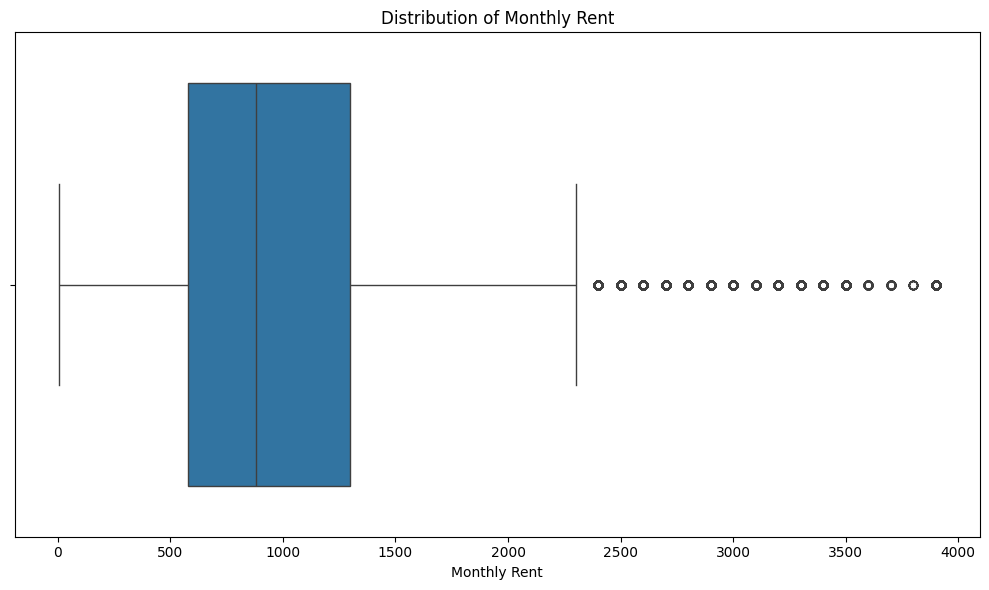

In [195]:
plt.figure(figsize=(10, 6))
sb.boxplot(x=rntp)
plt.title("Distribution of Monthly Rent")
plt.xlabel("Monthly Rent")
plt.tight_layout()
plt.show()

From the boxplot, we observe that the monthly rent distribution is right-skewed, with several high-rent outliers. Most rental values are concentrated below the upper whisker, while a small number of expensive rental units extend the right tail of the distribution.

In [196]:
def rntp_proportion(less_than: int) -> None:
    total = rntp.count()
    p = len(rntp.loc[rntp <= less_than]) / total
    print(f"The proportion of the monthly rent that are have less than {less_than} is"
          f"{p: .3f}")

rntp_proportion(1000)
rntp_proportion(2000)
rntp_proportion(3000)

The proportion of the monthly rent that are have less than 1000 is 0.619
The proportion of the monthly rent that are have less than 2000 is 0.923
The proportion of the monthly rent that are have less than 3000 is 0.983


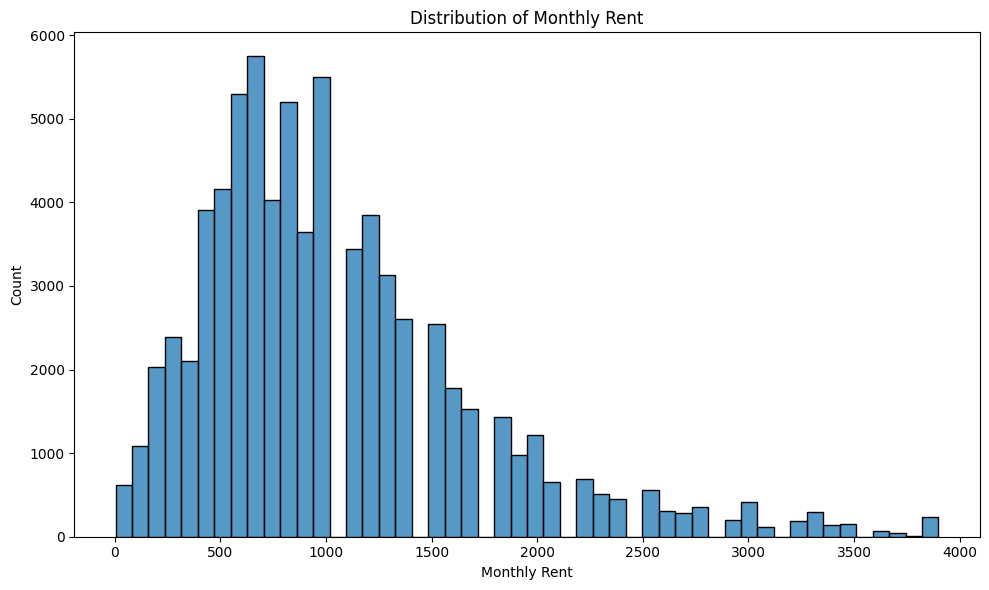

In [197]:
plt.figure(figsize=(10, 6))
sb.histplot(rntp, bins=50)
plt.title("Distribution of Monthly Rent")
plt.xlabel("Monthly Rent")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### RNTP Monte Carlo Sampling

In [198]:
sample_size = 100
n_trials = 10000

simRNTP = pd.Series([
    rntp.sample(sample_size, replace=True).mean()
    for _ in range(n_trials)
])

In [199]:
print("=== Monte Carlo Sampling of 100 Samples and 10,000 Trials ===")
simRNTP.describe()

=== Monte Carlo Sampling of 100 Samples and 10,000 Trials ===


count    10000.000000
mean      1031.032026
std         66.743384
min        793.400000
25%        985.175000
50%       1029.500000
75%       1074.900000
max       1319.700000
dtype: float64

Text(0.5, 0, 'Sample Mean of Monthly Rent')

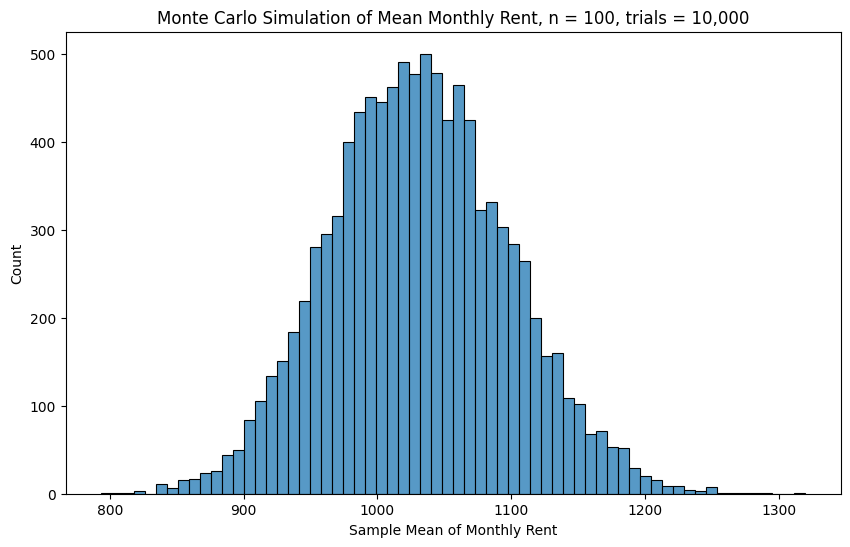

In [200]:
simRNTP = pd.Series(simRNTP)

plt.figure(figsize=(10, 6))
plt.title("Monte Carlo Simulation of Mean Monthly Rent, n = 100, trials = 10,000")
sb.histplot(data=simRNTP)
plt.xlabel("Sample Mean of Monthly Rent")


In [201]:
print("===== Monte Carlo Simulation: Monthly Rent =====")
print(f"Sample size: {sample_size}")
print(f"Number of trials: {n_trials}")
print(f"Simulation mean: {simRNTP.mean():.2f}")
print(f"Simulation standard deviation: {simRNTP.std():.2f}")
print(f"Population mean: {rntp.mean():.2f}")
print(f"Theoretical standard error: {rntp.std() / np.sqrt(sample_size):.2f}")

===== Monte Carlo Simulation: Monthly Rent =====
Sample size: 100
Number of trials: 10000
Simulation mean: 1031.03
Simulation standard deviation: 66.74
Population mean: 1030.91
Theoretical standard error: 66.34


The Monte Carlo simulation shows that the distribution of sample mean monthly rent is approximately bell-shaped when the sample size is 100. Although the original rent distribution is right-skewed, the sampling distribution of the mean becomes more symmetric due to the Central Limit Theorem.

The simulation mean is close to the population mean, and the simulation standard deviation is close to the theoretical standard error.

## Monthly Rent by Region

In [202]:
rent_division = acs_selected.loc[rntp.index, "DIVISION_name"]
rent_division.value_counts().sort_index()

DIVISION_name
East North Central (Midwest region)     9477
East South Central (South region)       4082
Middle Atlantic (Northeast region)     10026
Mountain (West region)                  5305
New England (Northeast region)          3527
Pacific (West region)                  13756
South Atlantic (South region)          14879
West North Central (Midwest region)     3938
West South Central (South Region)       8914
Name: count, dtype: int64

In [203]:
# Create a copy
rent_data = acs_selected.loc[acs_selected["RNTP"].notna(), 
                             ["RNTP", "DIVISION_name"]].copy()
rent_data.head()

,RNTP,DIVISION_name
2,120.0,East South Central (South region)
3,650.0,East South Central (South region)
4,950.0,East South Central (South region)
11,400.0,East South Central (South region)
15,300.0,East South Central (South region)


In [204]:
rent_summary = (
    rent_data
    .groupby("DIVISION_name")["RNTP"]
    .agg(["count", "mean", "median", "std"])
    .sort_index()
)
print(rent_summary)

                                     count         mean  median         std
DIVISION_name                                                              
East North Central (Midwest region)   9477   773.838134   680.0  477.303442
East South Central (South region)     4082   647.792259   590.0  388.324840
Middle Atlantic (Northeast region)   10026  1170.289647  1000.0  744.121191
Mountain (West region)                5305   984.666541   900.0  530.560295
New England (Northeast region)        3527  1142.928268  1000.0  703.550623
Pacific (West region)                13756  1432.417999  1300.0  767.092618
South Atlantic (South region)        14879  1014.553397   900.0  614.958893
West North Central (Midwest region)   3938   699.182834   600.0  432.081258
West South Central (South Region)     8914   860.342158   780.0  487.587279


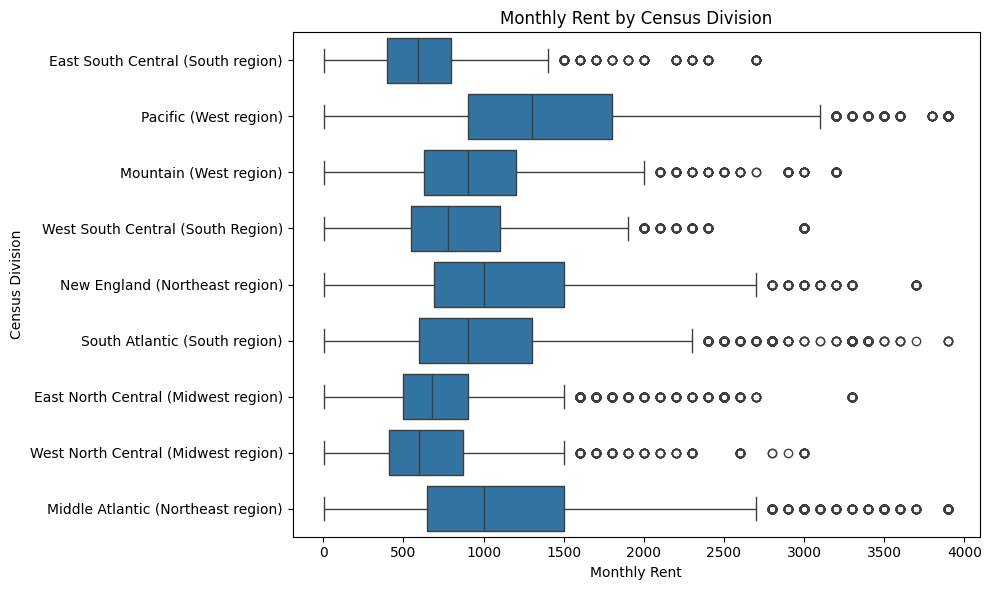

In [205]:
plt.figure(figsize=(10, 6))

sb.boxplot(rent_data, x="RNTP", y="DIVISION_name")

plt.title("Monthly Rent by Census Division")
plt.xlabel("Monthly Rent")
plt.ylabel("Census Division")
plt.tight_layout()
plt.show()

## Household Income

In [206]:
income = acs_selected["HINCP"].dropna()
print("===== Household Income Summary =====")
income.describe()

===== Household Income Summary =====


count    2.510190e+05
mean     8.965029e+04
std      1.000946e+05
min     -1.640000e+04
25%      3.180000e+04
50%      6.300000e+04
75%      1.110000e+05
max      2.580000e+06
Name: HINCP, dtype: float64

Text(0.5, 1.0, 'Distribution of Household Income')

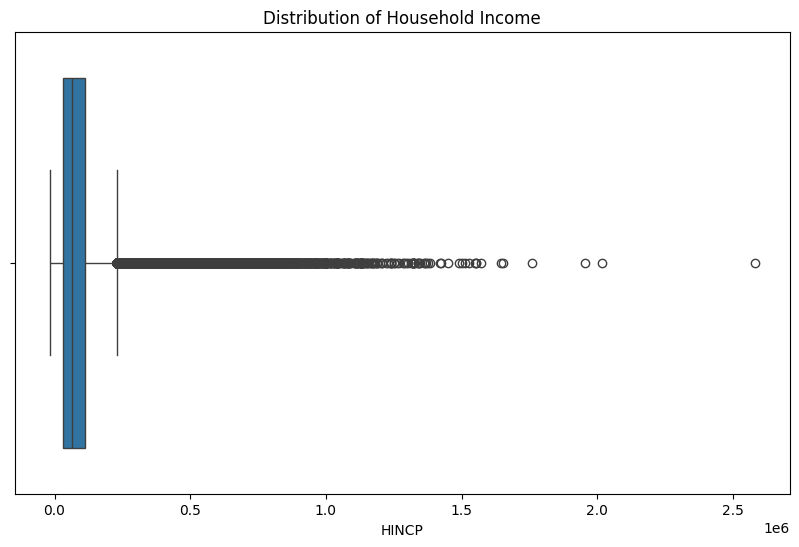

In [207]:
plt.figure(figsize=(10, 6))
sb.boxplot(x=income)
plt.title("Distribution of Household Income")


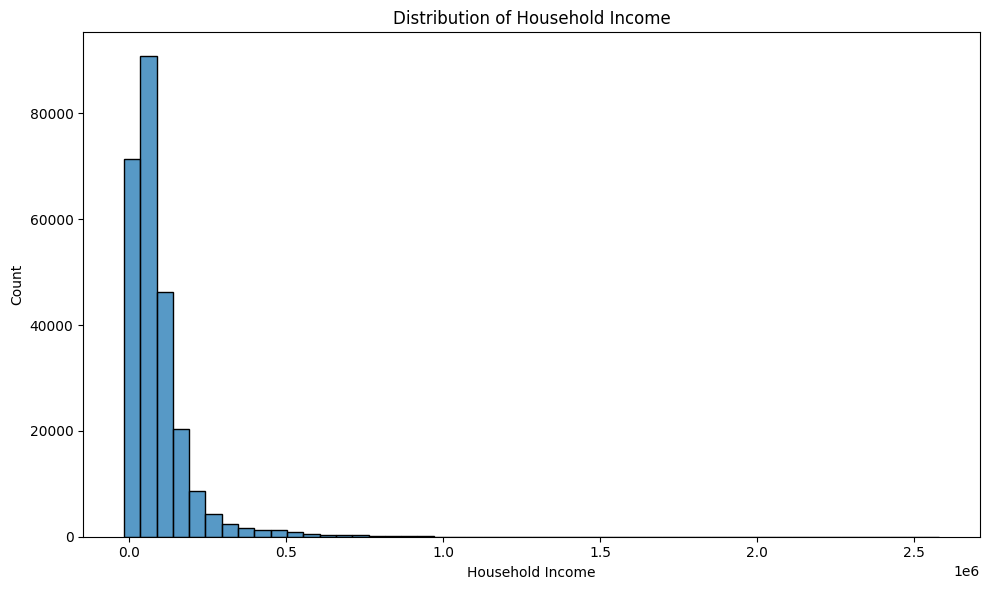

In [208]:
plt.figure(figsize=(10, 6))
sb.histplot(income, bins=50)
plt.title("Distribution of Household Income")
plt.xlabel("Household Income")
plt.ylabel("Count")
plt.tight_layout()

### Adjusted Household Income
Since household income is highly right-skewed, a log transformation is used to better visualize the distribution.

In [209]:
income_adj = np.log10(income[income > 0])

Text(0, 0.5, 'Count')

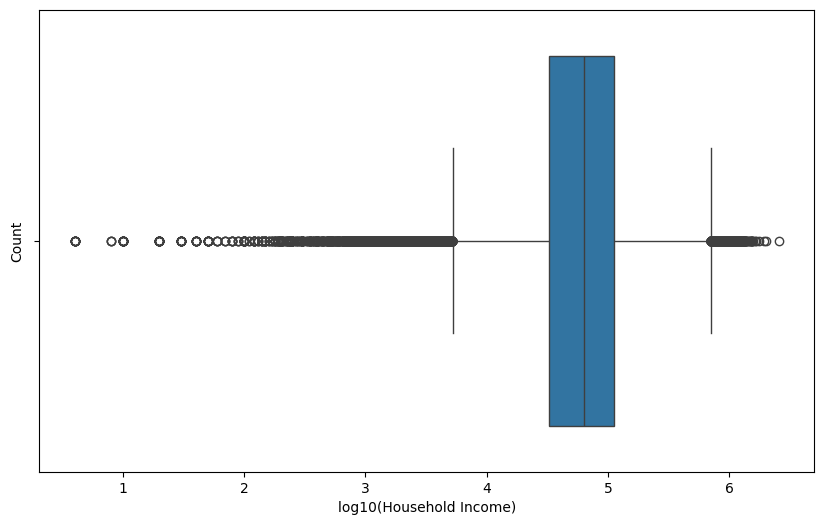

In [210]:
plt.figure(figsize=(10, 6))
sb.boxplot(x=income_adj)
plt.xlabel("log10(Household Income)")
plt.ylabel("Count")

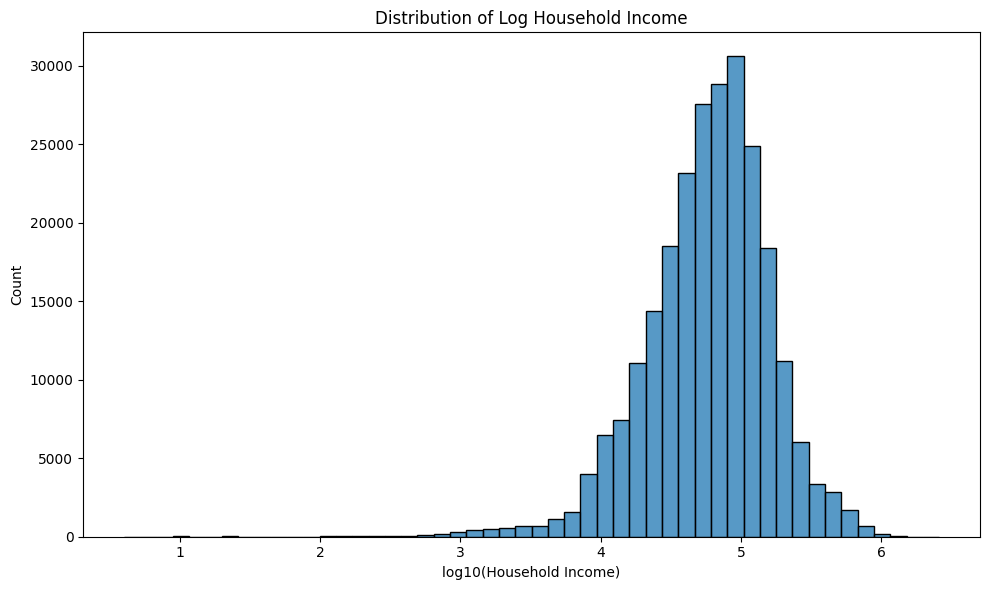

In [211]:
plt.figure(figsize=(10, 6))
sb.histplot(income_adj, bins=50)
plt.title("Distribution of Log Household Income")
plt.xlabel("log10(Household Income)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Household Income Distribution
Household income is strongly right-skewed. The median household income is $63,000, while the mean is higher at about $89,650. This difference suggests that a small number of very high-income households pull the average upward. The middle 50% of households have incomes between $31,800 and $111,000. Because the maximum income reaches $2.58 million, the distribution has a long right tail.